well just ignore this file simple tunning nothing else you find best parameter in params so ignore this dont waste your time

In [ ]:
# well just ignore this file simple tunning nothing else you find best parameter in params so ignore this dont waste your time
#!/usr/bin/env python3

In [ ]:
# still reading fine waste your time

import pandas as pd
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics

# Import models and tools
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report

def tune_churn_simple():
    try:
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "churn_prediction"
        target_col = params.tasks[task_name].target.name

        logger.info(f"--- Starting hyperparameter tuning for task: {task_name} ---")

        preprocessed_dir = Path(config.data_preprocessing.root_dir) / task_name
        train_df = pd.read_csv(preprocessed_dir / "train_processed.csv")
        test_df = pd.read_csv(preprocessed_dir / "test_processed.csv")

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]

        models = {
            "RandomForestClassifier" : RandomForestClassifier(random_state=42),
            "XGBClassifier" : XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss")
        }

        model_params_grid = params["tasks"][task_name]["model_params_grid"]

        for model_name, model in models.items():
            logger.info("-------------------------------------------")
            logger.info(f" tuning start {model_name}")

            param_grid = model_params_grid[model_name]

            grid_search = GridSearchCV(
                estimator=model,
                param_grid = param_grid,
                cv=3,
                scoring='roc_auc',
                n_jobs = -1,
                verbose=1

            )

            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_

            print("\n" + "="*30)
            print(f"MODEL: {model_name}")
            print(f"Best Cross-Validation Score (ROC AUC): {grid_search.best_score_:.4f}")
            print("Best Parameters Found:")
            print(grid_search.best_params_)
            
            print(f"for {model_name}")
            results_df = pd.DataFrame(grid_search.cv_results_)
            results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
            results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
            print("\nTop 5 Hyperparameter Combinations:")
            print(results_df_sorted.head(5).to_string(index=False))
   
            # Test set par final performance 
            y_pred = best_model.predict(X_test)
            print("\nTest Set par Classification Report:")
            print(classification_report(y_test, y_pred))
            print("="*30 + "\n")


    except Exception as e:
        logger.error(f"Error during hyperparameter tuning for task '{task_name}': {e}")
        raise e


tune_churn_simple()

[2025-10-10 19:54:02,190] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-10 19:54:02,211] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-10 19:54:02,213] INFO - 3287301645 - --- Starting hyperparameter tuning for task: churn_prediction ---
[2025-10-10 19:54:02,367] INFO - 3287301645 - -------------------------------------------
[2025-10-10 19:54:02,368] INFO - 3287301645 -  tuning start RandomForestClassifier
Fitting 3 folds for each of 1 candidates, totalling 3 fits

MODEL: RandomForestClassifier
Best Cross-Validation Score (ROC AUC): 0.8161
Best Parameters Found:
{'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
for RandomForestClassifier

Top 5 Hyperparameter Combinations:
                                                                                                                                    params  mean_test_score  std_tes

d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:08:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL: XGBClassifier
Best Cross-Validation Score (ROC AUC): 0.8772
Best Parameters Found:
{'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 1.5, 'scale_pos_weight': 2.5, 'subsample': 0.8}
for XGBClassifier

Top 5 Hyperparameter Combinations:
                                                                                                                                                                            params  mean_test_score  std_test_score  rank_test_score
{'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 1.5, 'scale_pos_weight': 2.5, 'subsample': 0.8}         0.877247        0.002985                1
  {'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 400, 'reg_alpha': 0.5, 'reg_lambda': 1.5, 'scale_pos_weight': 2, 'subsample': 0.8}         0.877000        0.003061       

In [ ]:
# hmm ignore this file i did tunning in notebook

import pandas as pd
import numpy as np
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics

# Import models and tools
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, f1_score

def tune_churn_simple():
    try:
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "churn_prediction"
        target_col = params.tasks[task_name].target.name

        logger.info(f"--- Starting hyperparameter tuning for task: {task_name} ---")

        preprocessed_dir = Path(config.data_preprocessing.root_dir) / task_name
        train_df = pd.read_csv(preprocessed_dir / "train_processed.csv")
        test_df = pd.read_csv(preprocessed_dir / "test_processed.csv")

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]

        models = {
            # "RandomForestClassifier" : RandomForestClassifier(random_state=42),
            "XGBClassifier" : XGBClassifier(random_state=42, use_label_encoder=False, eval_metric=['auc', 'logloss'])
        }

        model_params_grid = params["tasks"][task_name]["model_params_grid"]

        for model_name, model in models.items():
            logger.info("-------------------------------------------")
            logger.info(f" tuning start {model_name}")

            param_grid = model_params_grid[model_name]

            grid_search = GridSearchCV(
                estimator=model,
                param_grid = param_grid,
                cv=3,
                scoring='roc_auc',
                n_jobs = -1,
                verbose=1

            )

            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_

            print("\n" + "="*30)
            print(f"MODEL: {model_name}")
            print(f"Best Cross-Validation Score (ROC AUC): {grid_search.best_score_:.4f}")
            print("Best Parameters Found:")
            print(grid_search.best_params_)
            
            print(f"for {model_name}")
            results_df = pd.DataFrame(grid_search.cv_results_)
            results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
            results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
            print("\nTop 5 Hyperparameter Combinations:")
            print(results_df_sorted.head(5).to_string(index=False))
   
            # Test set par final performance 
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]

            # ADD THIS ENTIRE NEW BLOCK:
            logger.info("--- Finding optimal prediction threshold ---")
            thresholds = np.arange(0.1, 1.0, 0.01)
            f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]

            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx]

            logger.info(f"Optimal threshold found at: {optimal_threshold:.2f} with F1-Score: {f1_scores[optimal_idx]:.4f}")

            print("\nTest Set par Classification Report:")
            y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

            print("\n" + "="*50)
            print(f"FINAL CLASSIFICATION REPORT (with optimal threshold of {optimal_threshold:.2f})")
            print("="*50)
            print(classification_report(y_test, y_pred_optimal))
            
            print(classification_report(y_test, y_pred_proba))
            print("="*30 + "\n")


    except Exception as e:
        logger.error(f"Error during hyperparameter tuning for task '{task_name}': {e}")
        raise e


tune_churn_simple()

[2025-10-11 14:30:21,359] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:30:21,376] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-11 14:30:21,379] INFO - 2462217520 - --- Starting hyperparameter tuning for task: churn_prediction ---
[2025-10-11 14:30:21,554] INFO - 2462217520 - -------------------------------------------
[2025-10-11 14:30:21,555] INFO - 2462217520 -  tuning start XGBClassifier
Fitting 3 folds for each of 1 candidates, totalling 3 fits


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:30:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL: XGBClassifier
Best Cross-Validation Score (ROC AUC): 0.8789
Best Parameters Found:
{'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0.5, 'reg_lambda': 1.5, 'scale_pos_weight': 2.5, 'subsample': 0.8}
for XGBClassifier

Top 5 Hyperparameter Combinations:
                                                                                                                                                                            params  mean_test_score  std_test_score  rank_test_score
{'colsample_bytree': 0.9, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0.5, 'reg_lambda': 1.5, 'scale_pos_weight': 2.5, 'subsample': 0.8}         0.878898        0.002731                1
[2025-10-11 14:30:28,132] INFO - 2462217520 - --- Finding optimal prediction threshold ---
[2025-10-11 14:30:28,342] INFO - 2462217520 - Optimal threshold found at: 0.65 with F1-Score: 0.8804

Test Set par Classificati

Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\2462217520.py", line 102, in <module>
    tune_churn_simple()
    ~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\2462217520.py", line 99, in tune_churn_simple
    raise e
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\2462217520.py", line 93, in tune_churn_simple
    print(classification_report(y_test, y_pred_proba))
          ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\metrics\_classification.py", line 2948, in classification_report
    y_type, y_true

In [ ]:
# still looking fine read full 


from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
# Import our new helper functions
from src.utils.model_utils import load_processed_data, save_model_and_metrics, evaluate_classification_model

# Import the model
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_auc_score, classification_report, make_scorer, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd

def train_churn_model():
    """
    A dedicated script to train the churn prediction model.
    """
    try:
        # 1. Load Configs
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "churn_prediction"
        target_col = params['tasks'][task_name]['target']['name']
        
        logger.info(f"--- Starting training for: {task_name} ---")

        # 2. Load Data (using our utility function)
        train_df, test_df = load_processed_data(task_name)

        # 3. Prepare data for training
        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]

        grid = params['tasks'][task_name]['model_params_grid']["XGBClassifier"]

        # 4. Define and Train the Model
        logger.info("Initializing and xgbclassifier model.")
        model = XGBClassifier(
            n_estimators=grid['n_estimators'][0],
            learning_rate=grid['learning_rate'][0],
            max_depth=grid['max_depth'][0],
            subsample=grid['subsample'][0],
            colsample_bytree=grid['colsample_bytree'][0],
            gamma=grid['gamma'][0],
            reg_lambda=grid['reg_lambda'][0],
            scale_pos_weight=grid['scale_pos_weight'][0],
            reg_alpha=grid['reg_alpha'][0],
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            random_state=42,
            cv=3
        )
        model.fit(X_train, y_train)
        logger.info("Model training complete.")

        # 5. Evaluate the Model
        logger.info("Evaluating model on the test set.")
        y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of class 1 (churn)
        y_predict = (y_pred_proba >= 0.63).astype(int)
        metrics = evaluate_classification_model(y_test, y_predict)
        print(classification_report(y_test, y_predict))

        # 6. Save Everything (using our utility function)
        save_model_and_metrics(model, metrics, task_name)
        logger.info(f"Successfully completed training for {task_name}")

        


    except Exception as e:
        logger.error(f"Error in churn model training script: {e}")
        raise e

if __name__ == '__main__':
    train_churn_model()

[2025-10-11 14:34:37,117] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:34:37,133] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-11 14:34:37,136] INFO - 385095754 - --- Starting training for: churn_prediction ---
[2025-10-11 14:34:37,139] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:34:37,283] INFO - model_utils - Loaded train ((79552, 26)) and test ((19889, 26)) data for churn_prediction
[2025-10-11 14:34:37,289] INFO - 385095754 - Initializing and xgbclassifier model.


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:34:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[2025-10-11 14:34:38,465] INFO - 385095754 - Model training complete.
[2025-10-11 14:34:38,466] INFO - 385095754 - Evaluating model on the test set.
[2025-10-11 14:34:38,506] INFO - model_utils - Classification Metrics: {'roc_auc': 0.7253816916314529, 'f1_score': 0.8795749315204119}
              precision    recall  f1-score   support

           0       0.77      0.51      0.61      5685
           1       0.83      0.94      0.88     14204

    accuracy                           0.82     19889
   macro avg       0.80      0.73      0.75     19889
weighted avg       0.81      0.82      0.80     19889

[2025-10-11 14:34:38,519] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:34:38,521] INFO - common - Created directory at: artifacts\models
[2025-10-11 14:34:38,543] INFO - model_utils - Model for 'churn_prediction' saved to artifacts\models\churn_prediction_model.pkl
[2025-10-11 14:34:38,544] INFO - model_utils - Metrics for 'churn_prediction' saved 

In [45]:
from joblib import load
model = load("artifacts/models/churn_prediction_model.pkl")


In [46]:
config = read_yaml(Path("configs/config.yaml"))
params = read_yaml(Path("configs/params.yaml"))
task_name = "churn_prediction"
target_col = params['tasks'][task_name]['target']['name']
        
logger.info(f"--- Starting training for: {task_name} ---")

        # 2. Load Data (using our utility function)
train_df, test_df = load_processed_data(task_name)

        # 3. Prepare data for training
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

[2025-10-11 14:37:18,583] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:37:18,597] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-11 14:37:18,599] INFO - 1473847888 - --- Starting training for: churn_prediction ---
[2025-10-11 14:37:18,601] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 14:37:18,742] INFO - model_utils - Loaded train ((79552, 26)) and test ((19889, 26)) data for churn_prediction


In [47]:
# Train and test performance
import numpy as np
from sklearn.metrics import roc_auc_score, classification_report
y_train_pred = model.predict(X_train)
y_test_p = model.predict(X_test)
y_test_pred = model.predict_proba(X_test)[:,1]
y_test_pred_proba = (y_test_pred >= 0.7)

train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC:  {test_auc:.4f}")
print(f"Train-Test AUC Gap: {abs(train_auc - test_auc):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_p))
print(classification_report(y_test, y_test_pred_proba))

# Interpretation hint
if train_auc - test_auc > 0.05:
    print("\nPossible Overfitting (Train >> Test)")
elif train_auc < 0.8 and test_auc < 0.8:
    print("\n Possible Underfitting (Both low AUC)")
else:
    print("\n Good generalization balance")


Train AUC: 0.9432
Test AUC:  0.8849
Train-Test AUC Gap: 0.0582

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.36      0.51      5685
           1       0.79      0.97      0.87     14204

    accuracy                           0.80     19889
   macro avg       0.82      0.67      0.69     19889
weighted avg       0.81      0.80      0.77     19889

              precision    recall  f1-score   support

           0       0.72      0.61      0.66      5685
           1       0.85      0.91      0.88     14204

    accuracy                           0.82     19889
   macro avg       0.79      0.76      0.77     19889
weighted avg       0.81      0.82      0.82     19889


Possible Overfitting (Train >> Test)


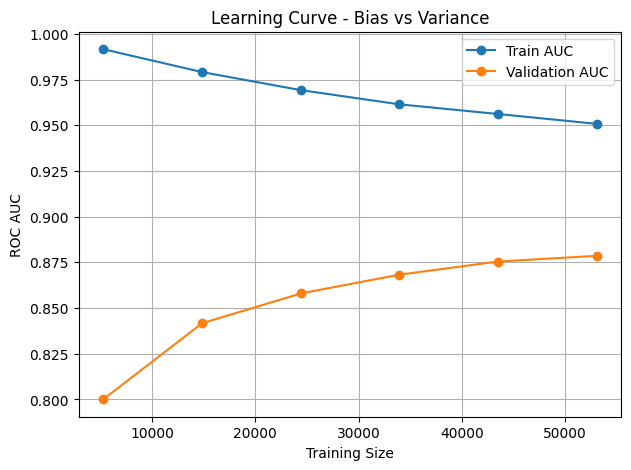

In [48]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True,
    random_state=42
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Train AUC")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validation AUC")
plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve - Bias vs Variance")
plt.legend()
plt.grid(True)
plt.show()


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Cross-Validation AUC Scores: {cv_scores}")
print(f"Mean AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

if cv_scores.std() > 0.02:
    print("\nModel variance high — try more regularization or cross-validation folds")
else:
    print("\nModel variance stable")


Cross-Validation AUC Scores: [0.88065943 0.88827306 0.8838109  0.88410788 0.88111952]
Mean AUC: 0.8836 ± 0.0027

Model variance stable


In [50]:
fold_results = []
for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_t, y_t)
    preds = model.predict_proba(X_v)[:, 1]
    auc_score = roc_auc_score(y_v, preds)
    fold_results.append(auc_score)
    print(f"Fold {i} AUC: {auc_score:.4f}")

print(f"\nMean CV AUC: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 AUC: 0.8798


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 AUC: 0.8873


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3 AUC: 0.8828


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4 AUC: 0.8837


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:37:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5 AUC: 0.8830

Mean CV AUC: 0.8833 ± 0.0024


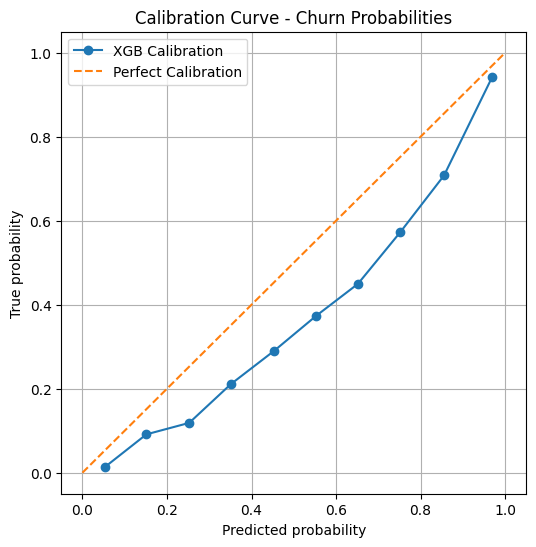

Brier Score (lower is better): 0.1379


In [39]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


y_prob = model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='XGB Calibration')
plt.plot([0,1],[0,1],'--', label='Perfect Calibration')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve - Churn Probabilities")
plt.legend()
plt.grid(True)
plt.show()

print(f"Brier Score (lower is better): {brier_score_loss(y_test, y_prob):.4f}")


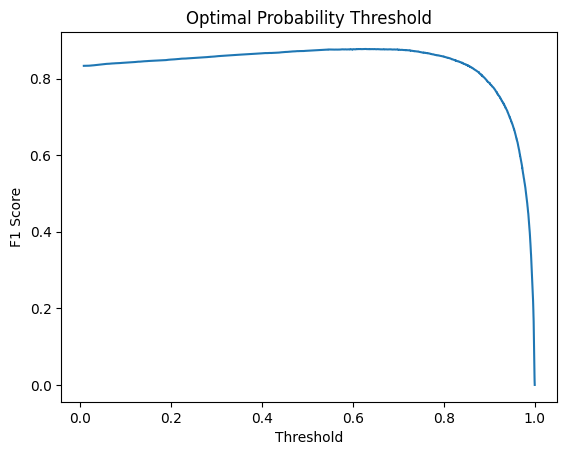

🔹 Best Threshold: 0.63
🔹 Max F1 Score: 0.8774


In [40]:
from sklearn.metrics import precision_recall_curve


y_proba = model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Optimal Probability Threshold")
plt.show()

print(f"🔹 Best Threshold: {best_threshold:.2f}")
print(f"🔹 Max F1 Score: {f1_scores[best_idx]:.4f}")


CUSTOMER SEGMENTATION START










[2025-10-11 16:13:55,180] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-11 16:13:55,224] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-11 16:13:55,230] INFO - 1335593065 - --- Starting Hybrid Tuning for: customer_segmentation ---
[2025-10-11 16:13:55,358] INFO - 1335593065 - Loaded full dataset ((99441, 5)) for customer_segmentation from artifacts\data_preprocessing\customer_segmentation\train_processed.csv
[2025-10-11 16:13:55,359] INFO - 1335593065 - Testing cluster numbers (k): [3, 4, 5, 6, 7, 8, 9, 10, 11]
[2025-10-11 16:13:55,360] INFO - 1335593065 - --- Evaluating for k = 3 ---
[2025-10-11 16:16:46,575] INFO - 1335593065 - For k = 3, best score found is 0.4199 (with params: {'n_init': 14})
[2025-10-11 16:16:46,577] INFO - 1335593065 - --- Evaluating for k = 4 ---
[2025-10-11 16:19:39,118] INFO - 1335593065 - For k = 4, best score found is 0.4377 (with params: {'n_init': 12})
[2025-10-11 16:19:39,122] INFO - 133559306

Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\1335593065.py", line 108, in <module>
    tune_segmentation_hybrid()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\1335593065.py", line 105, in tune_segmentation_hybrid
    raise e
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\1335593065.py", line 101, in tune_segmentation_hybrid
    save_model_and_metrics(best_model, metrics, task_name, config)
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: save_model_and_metrics() takes 3 positional arguments but 4 were given

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\si

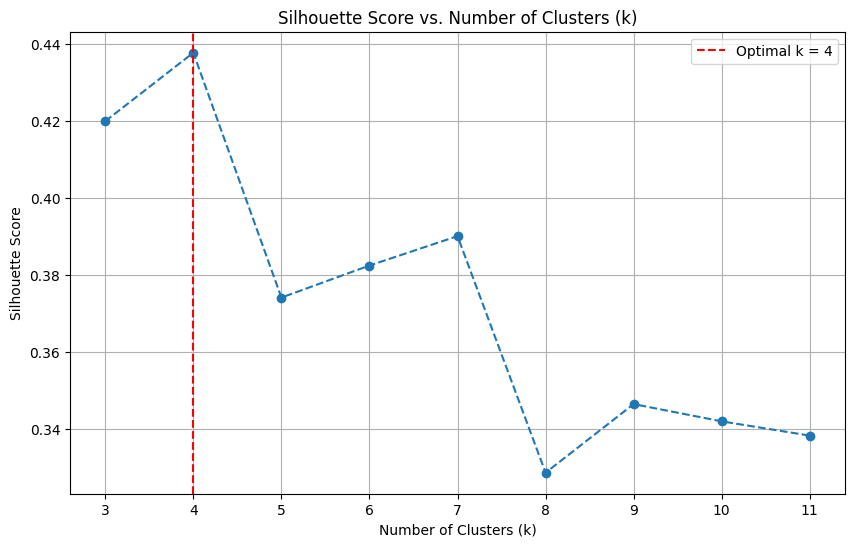

In [52]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics

# Import the necessary tools
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV

def tune_segmentation_hybrid():
    """
    Finds the optimal hyperparameters for KMeans using a hybrid approach:
    - An outer loop for 'n_clusters'.
    - An inner GridSearchCV for other params like 'n_init'.
    """
    try:
        # 1. Load Configs and Preprocessed Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "customer_segmentation"
        
        logger.info(f"--- Starting Hybrid Tuning for: {task_name} ---")

        preprocessed_dir = Path(config['data_preprocessing']['root_dir']) / task_name
        data_path = preprocessed_dir / "train_processed.csv"
        df = pd.read_csv(data_path)
        logger.info(f"Loaded full dataset ({df.shape}) for {task_name} from {data_path}")

        # 2. Set up the Hybrid Tuning Loop
        k_range = params['tasks'][task_name]['model_params_grid']['KMeans']['n_clusters']
        n_init_range = params['tasks'][task_name]['model_params_grid']['KMeans']['n_init']
        
        best_overall_score = -1
        best_model = None
        all_scores = []

        logger.info(f"Testing cluster numbers (k): {k_range}")

        # Outer loop for the number of clusters (k)
        for k in k_range:
            logger.info(f"--- Evaluating for k = {k} ---")
            
            # Inner GridSearchCV for other parameters (like n_init)
            inner_param_grid = {'n_init': n_init_range}
            
            # Note: We don't need 'scoring' or 'cv' here because we will score manually
            inner_search = GridSearchCV(
                estimator=KMeans(n_clusters=k, init='k-means++', random_state=42),
                param_grid=inner_param_grid,
                n_jobs=-1
            )
            
            inner_search.fit(df)
            
            # Get the best inner model for this specific k
            best_inner_model = inner_search.best_estimator_
            
            # Now, calculate the silhouette score on the full dataset, which is the correct method
            current_score = silhouette_score(df, best_inner_model.labels_)
            all_scores.append(current_score)
            logger.info(f"For k = {k}, best score found is {current_score:.4f} (with params: {inner_search.best_params_})")

            # Check if this is the best model overall
            if current_score > best_overall_score:
                best_overall_score = current_score
                best_model = best_inner_model
        
        # 3. Report the final best model found
        optimal_k = best_model.get_params()['n_clusters']
        logger.info("="*50)
        logger.info(f"OVERALL BEST MODEL FOUND:")
        logger.info(f"Optimal number of clusters (k): {optimal_k}")
        logger.info(f"Best Silhouette Score: {best_overall_score:.4f}")
        logger.info(f"Full best parameters: {best_model.get_params()}")
        logger.info("="*50)

        # 4. Visualize the results
        plt.figure(figsize=(10, 6))
        plt.plot(k_range, all_scores, marker='o', linestyle='--')
        plt.title('Silhouette Score vs. Number of Clusters (k)')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Silhouette Score')
        plt.xticks(k_range)
        plt.grid(True)
        plt.axvline(x=optimal_k, color='r', linestyle='--', label=f"Optimal k = {optimal_k}")
        plt.legend()
        
        plot_path = "segmentation_hybrid_tuning_plot.png"
        plt.savefig(plot_path)
        logger.info(f"Saved tuning plot to {plot_path}")

        # 5. Save the best model and its score
        metrics = {
            "best_params": best_model.get_params(),
            "silhouette_score": best_overall_score
        }
        # save_model_and_metrics(best_model, metrics, task_name, config)

    except Exception as e:
        logger.error(f"Error in segmentation hybrid tuning script: {e}")
        raise e

if __name__ == '__main__':
    tune_segmentation_hybrid()

[2025-10-12 13:04:49,513] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 13:04:49,520] INFO - 697693446 - --- Visualizing final clusters for: customer_segmentation ---
[2025-10-12 13:04:49,699] INFO - 697693446 - Loaded full dataset ((99441, 5)) for customer_segmentation from artifacts\data_preprocessing\customer_segmentation\train_processed.csv
[2025-10-12 13:04:49,700] INFO - 697693446 - Training final KMeans model with k=4 and n_init=12...
[2025-10-12 13:04:50,161] INFO - 697693446 - Final model training complete.
[2025-10-12 13:04:50,163] INFO - 697693446 - Visualizing the final clusters using PCA.
[2025-10-12 13:04:57,298] INFO - 697693446 - Saved final cluster visualization to final_customer_segments_plot.png


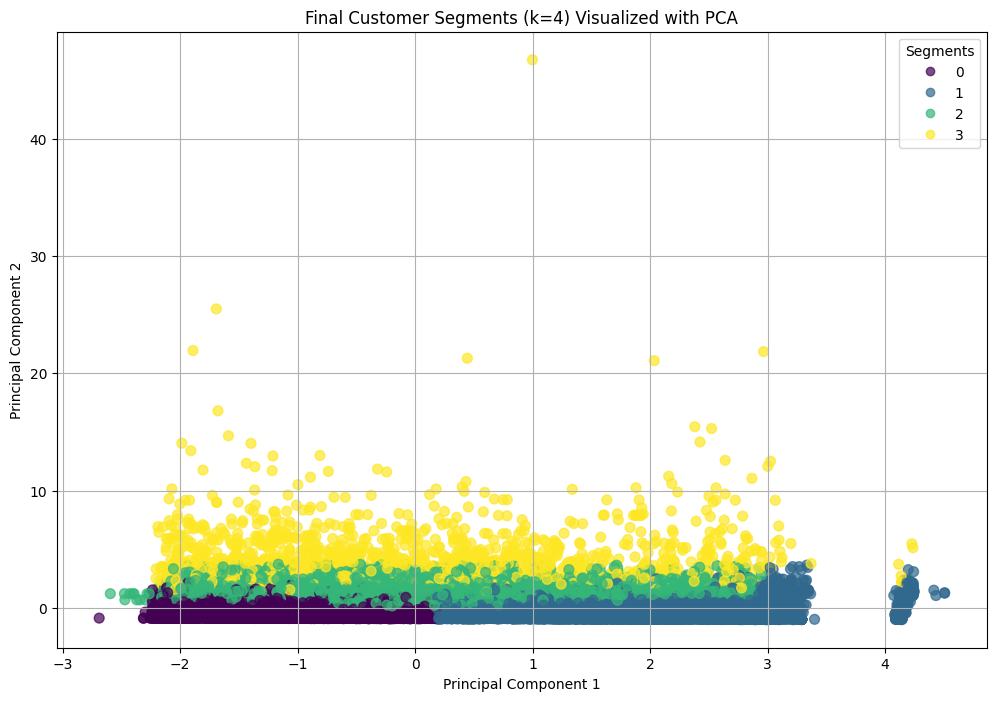

In [53]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from src.utils.logger import logger
from src.utils.common import read_yaml

# Import the necessary tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def visualize_final_segments():
    """
    Trains the single best KMeans model (k=4) and visualizes the resulting clusters.
    """
    try:
        # 1. Load Configs and Preprocessed Data
        config = read_yaml(Path("configs/config.yaml"))
        task_name = "customer_segmentation"
        
        logger.info(f"--- Visualizing final clusters for: {task_name} ---")

        preprocessed_dir = Path(config['data_preprocessing']['root_dir']) / task_name
        data_path = preprocessed_dir / "train_processed.csv"
        df = pd.read_csv(data_path)
        logger.info(f"Loaded full dataset ({df.shape}) for {task_name} from {data_path}")

        # 2. Define and Train the Single Best Model
        # We use the best parameters found during your tuning phase.
        optimal_k = 4
        best_n_init = 12
        
        logger.info(f"Training final KMeans model with k={optimal_k} and n_init={best_n_init}...")
        
        best_model = KMeans(
            n_clusters=optimal_k,
            init='k-means++',
            n_init=best_n_init,
            random_state=42
        )
        best_model.fit(df)
        logger.info("Final model training complete.")

        # 3. Visualize the Final Clusters using PCA
        logger.info("Visualizing the final clusters using PCA.")
        
        # Use PCA to reduce data to 2 dimensions for plotting
        pca = PCA(n_components=2)
        df_pca = pca.fit_transform(df)
        
        # Create a new DataFrame for plotting
        pca_df = pd.DataFrame(data=df_pca, columns=['PC1', 'PC2'])
        pca_df['Cluster'] = best_model.labels_ # Add the cluster labels from our best model
        
        plt.figure(figsize=(12, 8))
        # Create a scatter plot, coloring each point by its cluster label
        scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.7)
        
        plt.title(f'Final Customer Segments (k={optimal_k}) Visualized with PCA')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        
        # Create a legend for the clusters
        plt.legend(handles=scatter.legend_elements()[0], labels=range(optimal_k), title="Segments")
        plt.grid(True)
        
        cluster_plot_path = "final_customer_segments_plot.png"
        plt.savefig(cluster_plot_path)
        logger.info(f"Saved final cluster visualization to {cluster_plot_path}")

    except Exception as e:
        logger.error(f"Error in segmentation visualization script: {e}")
        raise e

if __name__ == '__main__':
    visualize_final_segments()

In [ ]:
# src/training_scripts/train_segmentation.py

from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
# We only need the save_model_and_metrics utility this time
from src.utils.model_utils import save_model_and_metrics

# Import the model and the evaluation metric
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
from src.components.data_preprocessing import DataPreprocessing

def train_segmentation_model():
    """
    A dedicated script to train the customer segmentation model.
    """
    try:
        # 1. Load Configs
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "customer_segmentation"
        
        logger.info(f"--- Starting training for: {task_name} ---")

        # 2. Load Data
        # For segmentation, we use the full, preprocessed dataset, not a train/test split.
        # The preprocessor saved this as `train_processed.csv` inside the task folder.
        preprocessed_dir = Path(config['data_preprocessing']['root_dir']) / task_name
        data_path = preprocessed_dir / "train_processed.csv"
        df = pd.read_csv(data_path)
        logger.info(f"Loaded full dataset ({df.shape}) for {task_name} from {data_path}")

        # 3. Define and Train the Model
        # NOTE: This is an unsupervised task, so there's no y_train!
        logger.info("Initializing and training KMeans model.")
        model = KMeans(
            n_clusters=params['tasks'][task_name]['model_params_grid']["KMeans"]['n_clusters'],
            init=params['tasks'][task_name]['model_params_grid']["KMeans"]['init'],
            random_state=42,
            # n_jobs=-1,
            verbose=1,
            n_init=params['tasks'][task_name]['model_params_grid']["KMeans"]['n_init']
        )
        model.fit(df) # We fit on the entire dataframe
        logger.info("Model training complete.")

        # 4. Evaluate the Model
        logger.info("Evaluating model using Silhouette Score.")
        score = silhouette_score(df, model.labels_)
        metrics = {"silhouette_score": score}
        logger.info(f"Segmentation Metrics: {metrics}")

        # 5. Save Everything
        save_model_and_metrics(model, metrics, task_name)
        logger.info(f"Successfully completed training for {task_name}")

    except Exception as e:
        logger.error(f"Error in segmentation model training script: {e}")
        raise e

if __name__ == '__main__':
    # preprocessor = DataPreprocessing()
    # preprocessor.preprocess_task("customer_segmentation")
    train_segmentation_model()

[2025-10-12 13:14:50,906] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 13:14:50,925] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-12 13:14:50,929] INFO - 608209202 - --- Starting training for: customer_segmentation ---
[2025-10-12 13:14:51,038] INFO - 608209202 - Loaded full dataset ((99441, 5)) for customer_segmentation from artifacts\data_preprocessing\customer_segmentation\train_processed.csv
[2025-10-12 13:14:51,039] INFO - 608209202 - Initializing and training KMeans model.
Initialization complete
Iteration 0, inertia 221959.8852514526.
Iteration 1, inertia 166350.26982497732.
Iteration 2, inertia 151178.01479704646.
Iteration 3, inertia 147427.1869365345.
Iteration 4, inertia 146800.21335785495.
Iteration 5, inertia 146632.65908010246.
Iteration 6, inertia 146549.95767503095.
Iteration 7, inertia 146511.60260203946.
Iteration 8, inertia 146499.14176743786.
Iteration 9, inertia 146492.69980798682.
Iteration 10, i

CLV PREDICTION START
















In [ ]:
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from src.utils.logger import logger
from src.utils.common import read_yaml
# Import all our helper functions, including the new one
from src.utils.model_utils import load_processed_data, save_model_and_metrics, evaluate_regression_model

# Import the model
from xgboost import XGBRegressor # Make sure you have run: pip install xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV

def train_clv_model():
    
    try:
         
        logger.info("reading config and params")
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "clv_prediction"
        target_column = params.tasks[task_name].target.name
        logger.info(f"--- Starting training for: {task_name} ---")

        train_df, test_df = load_processed_data(task_name)

        X_train = train_df.drop(columns=[target_column])
        y_train = train_df[target_column]
        x_test = test_df.drop(columns=[target_column])
        y_test = test_df[target_column]

        models = {
            "XGBRegressor" : XGBRegressor(random_state=42),
            "RandomForestRegressor" : RandomForestRegressor(random_state=42)
         }
        model_grid = params['tasks'][task_name]['model_params_grid']
        for model_name, model in models.items():
            logger.info("-------------------------------------------")
            logger.info(f" training start {model_name}")
            param_grid = model_grid[model_name]
            gridSearch = GridSearchCV(
                estimator=model,
                param_grid = param_grid,
                cv=3,
                scoring='neg_root_mean_squared_error',
                n_jobs = -1,
                verbose=1
            )
            gridSearch.fit(X_train, y_train)
            best_model = gridSearch.best_estimator_
            print("\n" + "="*30)
            print(f"MODEL: {model_name}")
            print(f"Best Cross-Validation Score (): {gridSearch.best_score_:.4f}")
            print("Best Parameters Found:")
            print(gridSearch.best_params_)
            print(f"for {model_name}")
            results_df = pd.DataFrame(gridSearch.cv_results_)
            results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
            results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
            print("\nTop 5 Hyperparameter Combinations:")
            print(results_df_sorted.head(5).to_string(index=False))

            y_pred = best_model.predict(x_test)
            metric = evaluate_regression_model(y_test, y_pred)
            print("\nTest Set par Regression Report:")
            print(metric)
        
        # metrics = evaluate_regression_model(y_test, y_pred)
        # save_model_and_metrics(model, metrics, task_name)
        logger.info(f"Successfully completed training for {task_name}")

    except Exception as e:
        logger.error(f"Error in CLV model training script: {e}")
        raise e

if __name__ == '__main__':
    train_clv_model()

[2025-10-12 13:44:09,157] INFO - 620655065 - reading config and params
[2025-10-12 13:44:09,162] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 13:44:09,180] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-12 13:44:09,184] INFO - 620655065 - --- Starting training for: clv_prediction ---
[2025-10-12 13:44:09,193] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 13:44:09,671] INFO - model_utils - Loaded train ((79552, 21)) and test ((19889, 21)) data for clv_prediction
[2025-10-12 13:44:09,695] INFO - 620655065 - -------------------------------------------
[2025-10-12 13:44:09,698] INFO - 620655065 -  training start XGBRegressor
Fitting 3 folds for each of 72 candidates, totalling 216 fits

MODEL: XGBRegressor
Best Cross-Validation Score (ROC AUC): -46.4218
Best Parameters Found:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
for XGBRegr

Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\620655065.py", line 76, in <module>
    train_clv_model()
    ~~~~~~~~~~~~~~~^^
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\620655065.py", line 73, in train_clv_model
    raise e
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_14152\620655065.py", line 63, in train_clv_model
    metric = evaluate_regression_model(y_test, y_pred)
  File "d:\projects\MLP1\src\utils\model_utils.py", line 100, in evaluate_regression_model
    """Calculates regression metrics."""
           ^^
NameError: name 'np' is not defined

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\IPython\c

In [8]:
import pandas as pd
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
# Make sure to import RandomizedSearchCV for faster tuning
from sklearn.model_selection import RandomizedSearchCV 
from src.utils.model_utils import save_model_and_metrics, load_processed_data

# Import models and regression metrics
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def tune_clv_model():
    """
    Tunes regression models for the CLV prediction task.
    """
    try:
        # 1. Load Configs and Preprocessed Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "clv_prediction"
        target_col = params['tasks'][task_name]['target']['name']
        
        logger.info(f"--- Starting hyperparameter tuning for: {task_name} ---")

        # FIX: The load_processed_data function needs the 'config' object
        train_df, test_df = load_processed_data(task_name)

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col]) # FIX: Renamed from x_test
        y_test = test_df[target_col]
        
        # 2. Define Models and Parameter Grids
        models = {
            "XGBRegressor": XGBRegressor(random_state=42),
            "RandomForestRegressor": RandomForestRegressor(random_state=42)
        }
        
        model_params_grid = params['tasks'][task_name]['model_params_grid']
        
        for model_name, model in models.items():
            logger.info("-------------------------------------------")
            logger.info(f"Tuning start for {model_name}")
            
            param_grid = model_params_grid[model_name]
            
            # Using RandomizedSearchCV is much faster for large grids
            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=param_grid,
                n_iter=20,  # Try 20 random combinations
                cv=3,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1,
                verbose=1,
                random_state=42
            )
            
            search.fit(X_train, y_train)
            
            best_model = search.best_estimator_
            
            # 3. Print the Corrected Report
            print("\n" + "="*50)
            print(f"MODEL: {model_name}")
            # FIX: Correctly label the score as Negative RMSE
            print(f"Best CV Score (Negative RMSE): {search.best_score_:.4f}")
            print("Best Parameters Found:")
            print(search.best_params_)
            
            results_df = pd.DataFrame(search.cv_results_)
            results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
            results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
            print("\nTop 5 Hyperparameter Combinations:")
            print(results_df_sorted.head(5).to_string(index=False))
            
            # Evaluate on the test set
            y_pred = best_model.predict(X_test)
            
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            print("\n\nTest Set Performance Report:")
            print(f"R-squared (R²): {r2:.4f}")
            print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
            print("="*50 + "\n")

    except Exception as e:
        logger.error(f"Error in CLV model tuning script: {e}")
        raise e

if __name__ == '__main__':
    tune_clv_model()

[2025-10-12 15:50:59,955] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 15:50:59,978] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-12 15:50:59,980] INFO - 541997329 - --- Starting hyperparameter tuning for: clv_prediction ---
[2025-10-12 15:50:59,983] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-12 15:51:00,205] INFO - model_utils - Loaded train ((79552, 28)) and test ((19889, 28)) data for clv_prediction
[2025-10-12 15:51:00,211] INFO - 541997329 - -------------------------------------------
[2025-10-12 15:51:00,211] INFO - 541997329 - Tuning start for XGBRegressor
Fitting 3 folds for each of 20 candidates, totalling 60 fits

MODEL: XGBRegressor
Best CV Score (Negative RMSE): -49.5769
Best Parameters Found:
{'subsample': 0.9, 'reg_lambda': 3, 'reg_alpha': 2, 'random_state': 42, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.08, 'gamma': 5, 'colsample_byt

d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
24 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_par


MODEL: RandomForestRegressor
Best CV Score (Negative RMSE): -44.9753
Best Parameters Found:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

Top 5 Hyperparameter Combinations:
                                                                                                                           params  mean_test_score  std_test_score  rank_test_score
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}       -44.975311        8.674629                1
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}       -46.655255        7.205576                2
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}       -48.366045        8.049392                3
{'n_estimators': 300,

In [10]:
# prepare_future_clv.py

import pandas as pd
import joblib
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml

def prepare_future_clv_data_advanced():
    """
    Creates a feature-rich dataset for predicting FUTURE CLV. It correctly
    re-creates the features needed for the segmentation model based on historical data.
    """
    try:
        logger.info("--- Starting ADVANCED Feature Engineering for Future CLV ---")
        
        # 1. Load configs and all necessary raw data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        
        order_data_path = "artifacts/data_preperation/" + params['data_ingestion']['source_order_filename']
        df_orders = pd.read_csv(order_data_path)
        
        # 2. Define Time Split
        df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
        cutoff_date = df_orders['order_purchase_timestamp'].quantile(0.7, interpolation='lower')
        logger.info(f"Using time-split cutoff date: {cutoff_date}")
        
        df_history = df_orders[df_orders['order_purchase_timestamp'] <= cutoff_date]
        df_future = df_orders[df_orders['order_purchase_timestamp'] > cutoff_date]
        
        # 3. Create a RICH set of historical features
        logger.info("Creating rich historical features...")
        df_features = df_history.groupby('customer_id').agg(
            total_orders_hist=('order_id', 'nunique'),
            total_items_hist=('order_item_id', 'count'),
            total_spent_hist=('payment_value', 'sum'),
            total_freight_hist=('freight_value', 'sum'),
            avg_review_score_hist=('review_score', 'mean'),
            first_order_date=('order_purchase_timestamp', 'min'),
            last_order_date_hist=('order_purchase_timestamp', 'max')
        ).reset_index()

        df_features['avg_price_hist'] = df_features['total_spent_hist'] / df_features['total_items_hist']
        df_features['avg_items_per_order_hist'] = df_features['total_items_hist'] / df_features['total_orders_hist']
        df_features['recency_hist'] = (cutoff_date - df_features['last_order_date_hist']).dt.days
        df_features['tenure_hist'] = (cutoff_date - df_features['first_order_date']).dt.days

        # 4. *** THE CRITICAL FIX: Prepare data for the segmentation model ***
        logger.info("Preparing historical data to predict segments...")
        
        # We create a new DataFrame with the EXACT column names the model was trained on.
        segmentation_features_for_pred = df_features[[
            'recency_hist',
            'total_orders_hist',
            'total_spent_hist',
            'avg_review_score_hist',
            'tenure_hist'
        ]].rename(columns={
            'recency_hist': 'days_since_last_order',
            'total_orders_hist': 'total_orders',
            'total_spent_hist': 'total_spent',
            'avg_review_score_hist': 'avg_review_score',
            'tenure_hist': 'customer_tenure_days'
        })
        
        # Load the saved segmentation preprocessor and model
        seg_preprocessor_path = Path(config['model_trainer']['trained_models_dir']) / "customer_segmentation_preprocessor.pkl"
        seg_model_path = Path(config['model_trainer']['trained_models_dir']) / "customer_segmentation_model.pkl"
        
        seg_preprocessor = joblib.load(seg_preprocessor_path)
        seg_model = joblib.load(seg_model_path)
        
        # Scale the data and predict the segment
        data_scaled = seg_preprocessor.transform(segmentation_features_for_pred)
        df_features['segment_id'] = seg_model.predict(data_scaled)
        logger.info("Successfully added historical 'segment_id' feature.")

        # 5. Create the Future Target
        df_target = df_future.groupby('customer_id').agg(future_spent=('payment_value', 'sum')).reset_index()
        
        # 6. Merge Everything and Finalize
        df_final = pd.merge(df_features, df_target, on='customer_id', how='left')
        df_final['future_spent'].fillna(0, inplace=True)
        
        # Drop helper columns that are not needed for the final model
        df_final.drop(columns=['first_order_date', 'last_order_date_hist'], inplace=True)
        
        # 7. Save the new, powerful dataset
        output_path = "artifacts/data_preperation/future_clv_dataset_advanced.csv"
        df_final.to_csv(output_path, index=False)
        logger.info(f"Successfully created ADVANCED future CLV dataset at: {output_path}")

    except Exception as e:
        logger.error(f"Error creating advanced future CLV data: {e}")
        raise e

if __name__ == '__main__':
    prepare_future_clv_data_advanced()

[2025-10-15 10:37:48,974] INFO - 890750753 - --- Starting ADVANCED Feature Engineering for Future CLV ---
[2025-10-15 10:37:48,978] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 10:37:48,989] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 10:37:49,985] INFO - 890750753 - Using time-split cutoff date: 2018-04-14 08:43:15
[2025-10-15 10:37:50,026] INFO - 890750753 - Creating rich historical features...
[2025-10-15 10:37:50,146] INFO - 890750753 - Preparing historical data to predict segments...
[2025-10-15 10:37:50,743] INFO - 890750753 - Successfully added historical 'segment_id' feature.


d:\projects\MLP1\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\Vansh\AppData\Local\Temp\ipykernel_33212\890750753.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['future_spent'].fillna(0, inplace=True)


[2025-10-15 10:37:51,033] INFO - 890750753 - Successfully created ADVANCED future CLV dataset at: artifacts/data_preperation/future_clv_dataset_advanced.csv


In [16]:
# src/tuning/tune_clv_original_improved.py

import pandas as pd
import numpy as np
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml

# Import all necessary tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

def tune_clv_original_improved():
    """
    Goes back to the original, reliable method of predicting 'total_spent'
    and improves it with new interaction features.
    """
    try:
        # 1. Load Configs and the ORIGINAL customer data
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "clv_prediction"
        
        logger.info(f"--- Tuning ORIGINAL CLV model with new features ---")
        
        # We will use the original customer file
        original_customer_file = "customer_features_advanced.csv" 
        data_path = "artifacts/data_preperation/" + original_customer_file
        df = pd.read_csv(data_path)
        df.dropna(inplace=True)

        # 2. *** NEW: Create Interaction Features ***
        logger.info("Creating new interaction features...")
        df['tenure_X_spending'] = df['customer_tenure_days'] * df['total_spent']
        df['review_X_orders'] = df['avg_review_score'] * df['total_orders']
        df['freight_per_order'] = df['total_freight'] / df['total_orders']
        
        # 3. Define Features (X) and Target (y)
        target_col = 'total_spent'
        
        # Use the original feature lists from your params.yaml and add our new ones
        numerical_features = params['tasks'][task_name]['numerical_features'] + [
            'tenure_X_spending', 
            'review_X_orders',
            'freight_per_order'
        ]
        categorical_features = params['tasks'][task_name]['categorical_features']
        
        X = df[numerical_features + categorical_features]
        y = df[target_col]

        # 4. Split and Preprocess the Data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        preprocessor = ColumnTransformer(transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # 5. Tune Models
        models = {
            "XGBRegressor": XGBRegressor(random_state=42),
            "RandomForestRegressor": RandomForestRegressor(random_state=42)
        }
        
        model_params_grid = params['tasks'][task_name]['model_params_grid']
        
        for model_name, model in models.items():
            logger.info(f"--- Tuning {model_name} with new features ---")
            param_grid = model_params_grid[model_name]
            
            random_search = RandomizedSearchCV(
                estimator=model, param_distributions=param_grid,
                n_iter=50, cv=5, scoring='neg_root_mean_squared_error',
                n_jobs=-1, verbose=1, random_state=42
            )
            
            random_search.fit(X_train_processed, y_train)
            
            best_model = random_search.best_estimator_
            
            print("\n" + "="*50)
            print(f"RESULTS FOR MODEL: {model_name}")
            print("="*50)
            print(f"Best CV Score (Negative RMSE): {random_search.best_score_:.4f}")
            print("Best Parameters:", random_search.best_params_)
            
            y_pred = best_model.predict(X_test_processed)
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            print("\nFinal Test Set Performance:")
            print(f"  R-squared (R²): {r2:.4f}")
            print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
            print("="*50 + "\n")

    except Exception as e:
        logger.error(f"Error in improved CLV tuning script: {e}")
        raise e

if __name__ == '__main__':
    tune_clv_original_improved()

[2025-10-15 11:36:47,945] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 11:36:47,947] INFO - 3794251598 - --- Tuning ORIGINAL CLV model with new features ---
[2025-10-15 11:36:48,221] INFO - 3794251598 - Creating new interaction features...
[2025-10-15 11:36:48,293] INFO - 3794251598 - --- Tuning XGBRegressor with new features ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RESULTS FOR MODEL: XGBRegressor
Best CV Score (Negative RMSE): -39.1287
Best Parameters: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'random_state': 42, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 3, 'colsample_bytree': 0.9}

Final Test Set Performance:
  R-squared (R²): 0.9117
  Root Mean Squared Error (RMSE): 63.3283

[2025-10-15 11:38:10,788] INFO - 3794251598 - --- Tuning RandomForestRegressor with new features ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits


d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
70 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_pa


RESULTS FOR MODEL: RandomForestRegressor
Best CV Score (Negative RMSE): -37.8659
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

Final Test Set Performance:
  R-squared (R²): 0.8797
  Root Mean Squared Error (RMSE): 73.9268



In [ ]:
# upgrade_customer_data.py

import pandas as pd
from pathlib import Path
from src.utils.logger import logger

def upgrade_customer_features():
    """
    Reads the original customer data, adds new interaction features,
    and overwrites the file with the upgraded version.
    """
    try:
        logger.info("--- Upgrading customer_ready.csv with new features ---")
        
        # Define the path to your main customer data file
        data_path = Path("artifacts/data_preperation/customer_features_advanced.csv")
        df = pd.read_csv(data_path)

        # Create the new interaction features
        logger.info("Creating new interaction features...")
        df['tenure_X_spending'] = df['customer_tenure_days'] * df['total_spent']
        df['review_X_orders'] = df['avg_review_score'] * df['total_orders']
        
        # Avoid division by zero for customers with no orders
        df['freight_per_order'] = (df['total_freight'] / df['total_orders']).fillna(0)
        
        # Overwrite the original file with the new, feature-rich version
        df.to_csv(data_path, index=False)
        
        logger.info(f"Successfully upgraded '{data_path}'. It now has {len(df.columns)} columns.")
        print("New features added:", ['tenure_X_spending', 'review_X_orders', 'freight_per_order'])

    except Exception as e:
        logger.error(f"Error during data upgrade: {e}")
        raise e

if __name__ == '__main__':
    upgrade_customer_features()


[2025-10-15 11:55:06,762] INFO - 3674058211 - --- Upgrading customer_ready.csv with new features ---
[2025-10-15 11:55:07,050] INFO - 3674058211 - Creating new interaction features...
[2025-10-15 11:55:07,825] INFO - 3674058211 - Successfully upgraded 'artifacts\data_preperation\customer_features_advanced.csv'. It now has 28 columns.
New features added: ['tenure_X_spending', 'review_X_orders', 'freight_per_order']


In [ ]:
# src/training_scripts/train_champion_clv.py

import pandas as pd
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics, load_processed_data

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def train_champion_clv_model():
    """
    Trains the single best CLV model (XGBoost) using the optimal hyperparameters.
    """
    try:
        # 1. Load Configs and Preprocessed Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "clv_prediction"
        target_col = params.tasks[task_name].target.name

        logger.info(f"--- Training CHAMPION model for task: {task_name} ---")
        train_df, test_df = load_processed_data(task_name)

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]

        # 2. Define the Champion Model with the BEST Hyperparameters
        paramGrid = params.tasks[task_name]['model_params_grid']['XGBRegressor']
        logger.info("Initializing XGBRegressor with the best hyperparameters.")
        champion_model = XGBRegressor(
            subsample=paramGrid['subsample'][0],
            reg_lambda=paramGrid['reg_lambda'][0],
            reg_alpha=paramGrid['reg_alpha'][0],
            n_estimators=paramGrid['n_estimators'][0],
            min_child_weight=paramGrid['min_child_weight'][0],
            max_depth=paramGrid['max_depth'][0],
            learning_rate=paramGrid['learning_rate'][0],
            gamma=paramGrid['gamma'][0],
            colsample_bytree=paramGrid['colsample_bytree'][0],
            random_state=42,
            n_jobs=-1
        )
        
        # 3. Train the single best model
        logger.info("Training the final model...")
        champion_model.fit(X_train, y_train)
        logger.info("Training complete.")

        # 4. Evaluate and display the final report
        y_pred = champion_model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        print("\n" + "="*50)
        print("FINAL CHAMPION MODEL REPORT")
        print("="*50)
        print(f"  R-squared (R²): {r2:.4f}")
        print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
        print("="*50)
        
        # 5. Save the final model
        final_metrics = {"r2_score": r2, "rmse": rmse}
        save_model_and_metrics(champion_model, final_metrics, "clv_prediction")

    except Exception as e:
        logger.error(f"Error during champion model training: {e}")
        raise e

if __name__ == '__main__':
    train_champion_clv_model()

[2025-10-15 13:10:01,406] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:10:01,425] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 13:10:01,428] INFO - 604248457 - --- Training CHAMPION model for task: clv_prediction ---
[2025-10-15 13:10:01,431] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:10:01,708] INFO - model_utils - Loaded train ((79552, 31)) and test ((19889, 31)) data for clv_prediction
[2025-10-15 13:10:01,717] INFO - 604248457 - Initializing XGBRegressor with the best hyperparameters.
[2025-10-15 13:10:01,718] INFO - 604248457 - Training the final model...
[2025-10-15 13:10:02,123] INFO - 604248457 - Training complete.

FINAL CHAMPION MODEL REPORT
  R-squared (R²): 0.9075
  Root Mean Squared Error (RMSE): 64.8441
[2025-10-15 13:10:02,140] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:10:02,142] INFO - common - Created directory at

CONVERSION PREDICTION STAR

















In [ ]:
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import load_processed_data, save_model_and_metrics, evaluate_classification_model

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np
# from configs import params


def train_conversion_model():
 try:
    config = read_yaml(Path("configs/config.yaml"))
    params = read_yaml(Path("configs/params.yaml"))
    task_name = "conversion_prediction"
    target_col = params.tasks[task_name].target.name

    train_df,test_df = load_processed_data("conversion_prediction")

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]
        
    models = {
        "LogisticRegression" : LogisticRegression(random_state=42, max_iter=500),
        "RandomForestClassifier" : RandomForestClassifier(random_state=42),
        "XGBClassifier" : XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
     }
    grid = params['tasks'][task_name]['model_params_grid']
    for model_name, model in models.items():
       logger.info("tunning starts-------------------------------------------")
       params_grid = grid[model_name]
       random_search = RandomizedSearchCV(
            estimator=model,
            n_iter=50,
            param_distributions=params_grid,
            cv=3,
            scoring='roc_auc',
            n_jobs = -1,
            verbose=1
        )
       random_search.fit(X_train, y_train)


       best_model = random_search.best_estimator_
       print(f"MODEL: {model_name}")
       print("\n" + "="*30)
       print(f"Best Cross-Validation Score (ROC AUC): {random_search.best_score_:.4f}")
       print("Best Parameters Found:")
       print(random_search.best_params_)
       
       print(f"for {model_name}")
       results_df = pd.DataFrame(random_search.cv_results_)
       results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
       results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
       print("\nTop 5 Hyperparameter Combinations:")
       print(results_df_sorted.head(5).to_string(index=False))
   
       # Test set par final performance 
       y_pred_proba = best_model.predict_proba(X_test)[:, 1]

       # ADD THIS ENTIRE NEW BLOCK:
       logger.info("--- Finding optimal prediction threshold ---")
       thresholds = np.arange(0.1, 1.0, 0.01)
       f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]

       optimal_idx = np.argmax(f1_scores)
       optimal_threshold = thresholds[optimal_idx]

       logger.info(f"Optimal threshold found at: {optimal_threshold:.2f} with F1-Score: {f1_scores[optimal_idx]:.4f}")

       print("\nTest Set par Classification Report:")
       y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

       print("\n" + "="*50)
       print(f"FINAL CLASSIFICATION REPORT (with optimal threshold of {optimal_threshold:.2f})")
       print("="*50)
       print(classification_report(y_test, y_pred_optimal))
       
    #    print(classification_report(y_test, y_pred_proba))
       print("="*30 + "\n")

       
 except Exception as e:  
    logger.error("error in train convertion model training pricing", e)
    raise e  
if __name__ == '__main__':
    train_conversion_model()

[2025-10-15 13:42:52,585] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:42:52,596] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 13:42:52,600] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:42:52,968] INFO - model_utils - Loaded train ((90740, 54)) and test ((22685, 54)) data for conversion_prediction
[2025-10-15 13:42:52,985] INFO - 4087314444 - tunning starts-------------------------------------------
Fitting 3 folds for each of 12 candidates, totalling 36 fits


d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


MODEL: LogisticRegression

Best Cross-Validation Score (ROC AUC): 0.8887
Best Parameters Found:
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}
for LogisticRegression

Top 5 Hyperparameter Combinations:
                                                                                            params  mean_test_score  std_test_score  rank_test_score
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}         0.888674        0.004041                1
        {'solver': 'saga', 'penalty': 'l2', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}         0.888620        0.004002                2
                    {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}         0.888562        0.004077                3
                    {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.1}         0.888538        0.004145                4
{

d:\projects\MLP1\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[2025-10-15 13:45:09,079] INFO - 4087314444 - Optimal threshold found at: 0.10 with F1-Score: 0.9866

Test Set par Classification Report:

FINAL CLASSIFICATION REPORT (with optimal threshold of 0.10)
              precision    recall  f1-score   support

           0       0.57      0.32      0.41       646
           1       0.98      0.99      0.99     22039

    accuracy                           0.97     22685
   macro avg       0.77      0.66      0.70     22685
weighted avg       0.97      0.97      0.97     22685

Unexpected exception formatting exception. Falling back to standard exception


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Vansh\AppData\Local\Temp\ipykernel_33212\4087314444.py", line 86, in train_conversion_model
    print(classification_report(y_test, y_pred_proba))
          ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\metrics\_classification.py", line 2948, in classification_report
    y_type, y_true, y_pred = _check_targets(y_true, y_pred)
                             ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "d:\projects\MLP1\venv\Lib\site-packages\sklearn\metrics\_classification.py", line 106, in _check_targets
    raise ValueError(
    ...<3 lines>...
    )
ValueError: Classification metrics can't handle a mix of binary and continuous targets

During handling of the above exception, another exception occurred:

Traceback (most recent call

In [33]:
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
# Make sure to import this function from your utils
from src.utils.model_utils import load_processed_data 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np

def train_conversion_model():
    try:
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "conversion_prediction"
        target_col = params.tasks[task_name].target.name

        # FIX #2: Pass the 'config' object to the function
        train_df, test_df = load_processed_data(task_name)

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]
        
        models = {
            "LogisticRegression": LogisticRegression(random_state=42, max_iter=500),
            "RandomForestClassifier": RandomForestClassifier(random_state=42),
            "XGBClassifier": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        }
        
        grid = params['tasks'][task_name]['model_params_grid']
        
        for model_name, model in models.items():
            logger.info(f"--- Tuning start for {model_name} ---")
            
            params_grid = grid[model_name]
            
            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=params_grid,
                n_iter=50,
                cv=3,
                scoring='roc_auc',
                n_jobs=-1,
                verbose=1,
                random_state=42
            )
            
            random_search.fit(X_train, y_train)
            
            best_model = random_search.best_estimator_
            
            print(f"\nMODEL: {model_name}")
            print("="*30)
            print(f"Best CV Score (ROC AUC): {random_search.best_score_:.4f}")
            print("Best Parameters Found:")
            print(random_search.best_params_)
            
            results_df = pd.DataFrame(random_search.cv_results_)
            results_df = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
            results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)
            print("\nTop 5 Hyperparameter Combinations:")
            print(results_df_sorted.head(5).to_string(index=False))
        
            # Find and apply optimal threshold
            logger.info("--- Finding optimal prediction threshold ---")
            y_pred_proba = best_model.predict_proba(X_test)[:, 1]
            
            thresholds = np.arange(0.1, 1.0, 0.01)
            f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]

            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx]

            logger.info(f"Optimal threshold found at: {optimal_threshold:.2f} with F1-Score: {f1_scores[optimal_idx]:.4f}")

            y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

            print("\n" + "="*50)
            print(f"FINAL CLASSIFICATION REPORT (with optimal threshold of {optimal_threshold:.2f})")
            print("="*50)
            print(classification_report(y_test, y_pred_optimal))
            
            # FIX #1: The incorrect line that caused the crash is now removed.
            
            print("="*30 + "\n")

    except Exception as e:
        logger.error(f"Error in train conversion model tuning: {e}")
        raise e

if __name__ == '__main__':
    train_conversion_model()

[2025-10-15 13:50:47,149] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:50:47,160] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 13:50:47,163] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 13:50:47,507] INFO - model_utils - Loaded train ((90740, 54)) and test ((22685, 54)) data for conversion_prediction
[2025-10-15 13:50:47,519] INFO - 904324166 - --- Tuning start for LogisticRegression ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits


d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=50. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



MODEL: LogisticRegression
Best CV Score (ROC AUC): 0.8887
Best Parameters Found:
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}

Top 5 Hyperparameter Combinations:
                                                                                            params  mean_test_score  std_test_score  rank_test_score
{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}         0.888674        0.004041                1
        {'solver': 'saga', 'penalty': 'l2', 'l1_ratio': 0.5, 'class_weight': 'balanced', 'C': 0.1}         0.888620        0.004002                2
                    {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}         0.888562        0.004077                3
                    {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.1}         0.888538        0.004145                4
{'solver': 'saga', 'penalty': 'elastic

d:\projects\MLP1\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 3 folds for each of 50 candidates, totalling 150 fits

MODEL: RandomForestClassifier
Best CV Score (ROC AUC): 0.9295
Best Parameters Found:
{'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 15, 'max_depth': 20, 'class_weight': 'balanced'}

Top 5 Hyperparameter Combinations:
                                                                                                   params  mean_test_score  std_test_score  rank_test_score
{'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 15, 'max_depth': 20, 'class_weight': 'balanced'}         0.929530        0.002933                1
{'n_jobs': -1, 'n_estimators': 200, 'min_samples_split': 15, 'max_depth': 20, 'class_weight': 'balanced'}         0.928597        0.002752                2
{'n_jobs': -1, 'n_estimators': 500, 'min_samples_split': 10, 'max_depth': 20, 'class_weight': 'balanced'}         0.928532        0.003538                3
 {'n_jobs': -1, 'n_estimators': 500, 'min_samples_split': 5, 'max_depth': 20, 'class_w

d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MODEL: XGBClassifier
Best CV Score (ROC AUC): 0.9358
Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_jobs': -1, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 3, 'colsample_bytree': 1.0}

Top 5 Hyperparameter Combinations:
                                                                                                                                                             params  mean_test_score  std_test_score  rank_test_score
{'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_jobs': -1, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 3, 'colsample_bytree': 1.0}         0.935848        0.002227                1
 {'subsample': 0.7, 'reg_lambda': 7, 'reg_alpha': 2, 'n_jobs': -1, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}         0.935565        0.003310                2
 {'subsample': 0.8, 'reg_lambda': 6, 'reg_alpha': 0, 'n_jobs': -1, 'n_estimators'

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import load_processed_data

# Import all necessary tools
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import SMOTE and Pipeline from imblearn
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

def tune_conversion_model_with_smote():
    """
    Tunes models for conversion prediction using a SMOTE pipeline
    to handle extreme class imbalance correctly.
    """
    try:
        # 1. Load Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "conversion_prediction"
        target_col = params.tasks[task_name].target.name

        logger.info(f"--- Starting Tuning for {task_name} with SMOTE ---")
        train_df, test_df = load_processed_data(task_name)

        X_train = train_df.drop(columns=[target_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col])
        y_test = test_df[target_col]
        
        # 2. Tune Models using a SMOTE Pipeline
        models = {
            "LogisticRegression": LogisticRegression(random_state=42, max_iter=500),
            "RandomForestClassifier": RandomForestClassifier(random_state=42),
            "XGBClassifier": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        }
        
        model_params_grid = params['tasks'][task_name]['model_params_grid']
        
        for model_name, model in models.items():
            logger.info(f"--- Tuning {model_name} with SMOTE ---")
            
            # Create a Pipeline that first applies SMOTE, then the model
            pipeline = Pipeline(steps=[
                ('smote', SMOTE(random_state=42)),
                ('model', model)
            ])
            
            # === THE FIX IS HERE ===
            param_grid = model_params_grid[model_name]
            
            # Check if the param_grid is a list (for LogisticRegression) or a dict
            if isinstance(param_grid, list):
                # If it's a list, loop through each dict and add the 'model__' prefix
                pipeline_param_grid = [{f'model__{key}': value for key, value in d.items()} for d in param_grid]
            else:
                # If it's a dict, just add the 'model__' prefix
                pipeline_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

            random_search = RandomizedSearchCV(
                estimator=pipeline,
                param_distributions=pipeline_param_grid,
                n_iter=30, cv=3, scoring='roc_auc',
                n_jobs=-1, verbose=1, random_state=42
            )
            
            random_search.fit(X_train, y_train)
            
            best_pipeline = random_search.best_estimator_
            
            # --- Print and Evaluate Results ---
            print("\n" + "="*50)
            print(f"RESULTS FOR MODEL: {model_name} with SMOTE")
            print("="*50)
            print(f"Best CV Score (ROC AUC): {random_search.best_score_:.4f}")
            print("Best Parameters:", random_search.best_params_)
            
            y_pred = best_pipeline.predict(X_test)
            
            print("\nFinal Test Set Report (with SMOTE):")
            print(classification_report(y_test, y_pred))
            print("="*50 + "\n")

    except Exception as e:
        logger.error(f"Error in conversion tuning script with SMOTE: {e}")
        raise e

if __name__ == '__main__':
    tune_conversion_model_with_smote()

[2025-10-15 14:45:12,000] INFO - common - YAML file 'configs\config.yaml' loaded successfully.


[2025-10-15 14:45:12,165] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 14:45:12,188] INFO - 1645707955 - --- Starting Tuning for conversion_prediction with SMOTE ---
[2025-10-15 14:45:12,228] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 14:45:15,685] INFO - model_utils - Loaded train ((90740, 54)) and test ((22685, 54)) data for conversion_prediction
[2025-10-15 14:45:15,790] INFO - 1645707955 - --- Tuning LogisticRegression with SMOTE ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits


d:\projects\MLP1\venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



RESULTS FOR MODEL: LogisticRegression with SMOTE
Best CV Score (ROC AUC): 0.8860
Best Parameters: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__class_weight': 'balanced', 'model__C': 0.1}

Final Test Set Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.15      0.85      0.26       646
           1       0.99      0.86      0.92     22039

    accuracy                           0.86     22685
   macro avg       0.57      0.85      0.59     22685
weighted avg       0.97      0.86      0.90     22685


[2025-10-15 14:52:41,444] INFO - 1645707955 - --- Tuning RandomForestClassifier with SMOTE ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits

RESULTS FOR MODEL: RandomForestClassifier with SMOTE
Best CV Score (ROC AUC): 0.9173
Best Parameters: {'model__n_jobs': -1, 'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Final Test Set Report (with S

d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:30:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



RESULTS FOR MODEL: XGBClassifier with SMOTE
Best CV Score (ROC AUC): 0.9222
Best Parameters: {'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 2, 'model__n_jobs': -1, 'model__n_estimators': 600, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__gamma': 1, 'model__colsample_bytree': 0.7}

Final Test Set Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.76      0.64      0.69       646
           1       0.99      0.99      0.99     22039

    accuracy                           0.98     22685
   macro avg       0.87      0.82      0.84     22685
weighted avg       0.98      0.98      0.98     22685




In [8]:
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import load_processed_data, save_model_and_metrics, evaluate_classification_model

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier

def train_conversion_model():
 try:
    config = read_yaml(Path("configs/config.yaml"))
    params = read_yaml(Path("configs/params.yaml"))
    task_name = "conversion_prediction"
    target_col = params['tasks'][task_name]['target']['name']

    train_df,test_df = load_processed_data("conversion_prediction")

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    params = params['tasks'][task_name]["model_params_grid"]["XGBClassifier"]
        
    model = XGBClassifier(
           n_estimators=params['n_estimators'][0],
           learning_rate=params['learning_rate'][0],
           max_depth=params['max_depth'][0],
           subsample=params['subsample'][0],
           colsample_bytree=params['colsample_bytree'][0],
           gamma=params['gamma'][0],
           reg_lambda=params['reg_lambda'][0],
           reg_alpha=params['reg_alpha'][0],
           n_jobs=params['n_jobs'][0],
           use_label_encoder=False,
        #    n_jobs=params['n_jobs'],
           random_state=42,
           eval_metric='logloss'
        )
    
    
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    # metrics = evaluate_classification_model(y_test, y_pred_proba)
    print("\n" + "="*50)
    print("FINAL CHAMPION MODEL REPORT")
    print("="*50)
    print(classification_report(y_test, y_pred))
    metrics = {"f1_score": f1_score(y_test, y_pred),"roc_auc": roc_auc_score(y_test, y_pred)}
    save_model_and_metrics(model, metrics, task_name)
    print(metrics)
    
 except Exception as e:  
    logger.error("error in train convertion model training pricing", e)
    raise e  
if __name__ == '__main__':
    train_conversion_model()

[2025-10-15 16:00:11,521] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 16:00:11,532] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-15 16:00:11,535] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 16:00:11,901] INFO - model_utils - Loaded train ((90740, 54)) and test ((22685, 54)) data for conversion_prediction


d:\projects\MLP1\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:00:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



FINAL CHAMPION MODEL REPORT
              precision    recall  f1-score   support

           0       0.76      0.64      0.69       646
           1       0.99      0.99      0.99     22039

    accuracy                           0.98     22685
   macro avg       0.87      0.82      0.84     22685
weighted avg       0.98      0.98      0.98     22685

[2025-10-15 16:00:17,156] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-15 16:00:17,157] INFO - common - Created directory at: artifacts\models
[2025-10-15 16:00:17,174] INFO - model_utils - Model for 'conversion_prediction' saved to artifacts\models\conversion_prediction_model.pkl
[2025-10-15 16:00:17,175] INFO - model_utils - Metrics for 'conversion_prediction' saved to artifacts\models\conversion_prediction_metrics.json
{'f1_score': 0.9917157084653689, 'roc_auc': 0.8158907576872241}


recommendation start






















In [16]:
# src/tuning/tune_recommender.py

import pandas as pd
from pathlib import Path
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics

# Import necessary tools from the 'surprise' library
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

def tune_recommender_model():
    """
    Tunes the SVD recommendation model using GridSearchCV from the surprise library
    and saves the best model trained on the full dataset.
    """
    try:
        # 1. Load Configs and Raw Order Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "recommendation_system"
        
        logger.info(f"--- Starting Hyperparameter Tuning for: {task_name} ---")

        # Load the raw order data, which has the user-item-rating information
        order_data_path = "artifacts/data_preperation/" + params['data_ingestion']['source_order_filename']
        df = pd.read_csv(order_data_path)
        
        # 2. Prepare Data for the 'surprise' Library
        logger.info("Preparing data for the surprise library...")
        recommender_df = df[['customer_id', 'product_id', 'review_score']].copy()
        recommender_df.dropna(inplace=True)
        
        rating_scale = tuple(params['tasks'][task_name]['rating_scale'])
        reader = Reader(rating_scale=rating_scale)
        
        data = Dataset.load_from_df(recommender_df, reader)
        
        # 3. Set up and Run GridSearchCV
        param_grid = params['tasks'][task_name]['model_params_grid']['SVD']
        logger.info(f"Tuning SVD with grid: {param_grid}")

        # Use the special GridSearchCV from 'surprise'
        gs = GridSearchCV(
            SVD,
            param_grid,
            measures=["rmse"], # We want to find the model with the LOWEST prediction error
            cv=3,
            n_jobs=-1
        )
        
        gs.fit(data)
        
        # 4. Report the Best Results from the search
        print("\n" + "="*50)
        print("TUNING RESULTS FOR SVD RECOMMENDER")
        print("="*50)
        # For RMSE, a lower score is better
        print(f"Best CV Score (RMSE): {gs.best_score['rmse']:.4f}")
        print("Best Parameters Found:")
        print(gs.best_params['rmse'])
        
        # 5. Train the Final Champion Model on the Full Dataset
        logger.info("Training the final champion model on the entire dataset...")
        
        best_params = gs.best_params['rmse']
        final_model = SVD(**best_params)
        
        # Build a training set from all available data to make the final model as smart as possible
        full_trainset = data.build_full_trainset()
        final_model.fit(full_trainset)
        
        logger.info("Final model training complete.")

        # 6. Save the Final Model and its performance metrics
        metrics = {
            "best_params": gs.best_params['rmse'],
            "best_cv_rmse": gs.best_score['rmse']
        }
        # Use your existing utility function to save everything
        # save_model_and_metrics(final_model, metrics, task_name, config)

        print("\nFinal Recommender Model Metrics:", metrics)

    except Exception as e:
        logger.error(f"Error in recommender tuning script: {e}")
        raise e

if __name__ == '__main__':
    tune_recommender_model()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\projects\MLP1\venv_py311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\projects\MLP1\venv_py311\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "d:\projects\MLP1\venv_py311\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "d:\projects\MLP1\venv_py311\L

ImportError: numpy.core.multiarray failed to import (auto-generated because you didn't call 'numpy.import_array()' after cimporting numpy; use '<void>numpy._import_array' to disable if you are certain you don't need it).

In [10]:
import pandas as pd
df_cust = pd.read_csv("artifacts/data_preperation/customer_features_advanced.csv")
# Find customers with more than 1 order
df_cust["total_orders"].value_counts()

total_orders
1    99441
Name: count, dtype: int64

In [21]:
import pandas as pd

# Load the raw order data
df_orders = pd.read_csv("artifacts/data_preperation/order_master_final_1.csv")

# Count how many times each customer appears (indicating multiple items/orders)
customer_counts = df_orders['customer_id'].value_counts()

# Find customers who appear more than once
customers_with_multiple_interactions = customer_counts[customer_counts > 1]

# Print the IDs of the first few customers with multiple interactions
print("Customer IDs with multiple interactions (good for testing):")
print(customers_with_multiple_interactions.head())

# Pick one of these IDs to test
test_customer_id = customers_with_multiple_interactions.index[0] 
print(f"\nUsing this ID for testing: {test_customer_id}")

Customer IDs with multiple interactions (good for testing):
customer_id
fc3d1daec319d62d49bfb5e1f83123e9    21
be1b70680b9f9694d8c70f41fa3dc92b    20
bd5d39761aa56689a265d95d8d32b8be    20
10de381f8a8d23fff822753305f71cae    15
adb32467ecc74b53576d9d13a5a55891    15
Name: count, dtype: int64

Using this ID for testing: fc3d1daec319d62d49bfb5e1f83123e9


In [13]:
# src/tuning/tune_recommender_implicit_als.py

import pandas as pd
from pathlib import Path
import numpy as np
from src.utils.logger import logger
from src.utils.common import read_yaml
from src.utils.model_utils import save_model_and_metrics

# Import tools for sparse matrices and the implicit library
from scipy.sparse import csr_matrix
import implicit.als # Import the ALS model

def tune_recommender_implicit_als():
    """
    Trains an ALS model from the 'implicit' library using a USER x ITEM sparse matrix.
    """
    try:
        # 1. Load Configs and Raw Order Data
        config = read_yaml(Path("configs/config.yaml"))
        params = read_yaml(Path("configs/params.yaml"))
        task_name = "recommendation_system"
        
        logger.info(f"--- Starting Training for: {task_name} using implicit ALS ---")

        order_data_path = "artifacts/data_preperation/" + params['data_ingestion']['source_order_filename']
        df = pd.read_csv(order_data_path)
        
        # 2. Prepare Data: Create Sparse User-Item Matrix (User x Item)
        logger.info("Preparing sparse user-item matrix...")
        user_col = params['tasks'][task_name]['user_col']
        item_col = params['tasks'][task_name]['item_col']
        rating_col = params['tasks'][task_name]['rating_col']
        
        df_ratings = df[[user_col, item_col, rating_col]].copy()
        df_ratings.dropna(inplace=True)
        
        # Create unique numerical IDs (important for implicit)
        df_ratings['user_id'] = df_ratings[user_col].astype('category').cat.codes
        df_ratings['item_id'] = df_ratings[item_col].astype('category').cat.codes
        
        n_users = df_ratings['user_id'].nunique()
        n_items = df_ratings['item_id'].nunique()
        
        # *** MAIN CHANGE: Create the User x Item matrix directly ***
        sparse_user_item = csr_matrix((df_ratings[rating_col], (df_ratings['user_id'], df_ratings['item_id'])),
                                      shape=(n_users, n_items))
        
        logger.info(f"Sparse user-item matrix created with shape: {sparse_user_item.shape}")

        # 3. Train ALS Model (Using simple default parameters for now)
        factors = 100 # Default number of factors
        regularization = 0.01
        iterations = 20
        
        logger.info(f"Training final ALS model with factors={factors}, regularization={regularization}, iterations={iterations}")
        
        model = implicit.als.AlternatingLeastSquares(
            factors=factors,
            regularization=regularization,
            iterations=iterations,
            random_state=42
        )
        
        # *** MAIN CHANGE: Train the model on the User x Item matrix ***
        # Implicit expects items x users internally, but passing users x items often works better
        # with the recommend function due to internal handling. Let's try this first.
        # If this still gives errors, we will pass sparse_user_item.T (transposed)
        model.fit(sparse_user_item)
        logger.info("ALS model training complete.")
        
        # 4. Save the Final Model and Configs Used
        metrics = {
            "model_type": "implicit ALS",
            "factors": factors,
            "regularization": regularization,
            "iterations": iterations
        }
        save_model_and_metrics(model, metrics, task_name)
        
        # 5. Save mappings for later use during prediction
        # Create mapping from numerical user_id back to original customer_id
        user_map_rev = dict(zip(df_ratings['user_id'], df_ratings[user_col]))
        # Create mapping from numerical item_id back to original product_id
        item_map_rev = dict(zip(df_ratings['item_id'], df_ratings[item_col]))
        
        pd.Series(user_map_rev).to_json(Path(config['model_trainer']['trained_models_dir']) / "user_map_rev.json")
        pd.Series(item_map_rev).to_json(Path(config['model_trainer']['trained_models_dir']) / "item_map_rev.json")
        logger.info("Saved user and item ID mappings.")

    except Exception as e:
        logger.error(f"Error in implicit ALS recommender script: {e}")
        raise e

if __name__ == '__main__':
    tune_recommender_implicit_als()

[2025-10-18 11:21:46,961] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-18 11:21:46,973] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-18 11:21:46,975] INFO - 3624864900 - --- Starting Training for: recommendation_system using implicit ALS ---
[2025-10-18 11:21:47,875] INFO - 3624864900 - Preparing sparse user-item matrix...
[2025-10-18 11:21:47,998] INFO - 3624864900 - Sparse user-item matrix created with shape: (98666, 32951)
[2025-10-18 11:21:47,999] INFO - 3624864900 - Training final ALS model with factors=100, regularization=0.01, iterations=20


100%|██████████| 20/20 [00:05<00:00,  3.68it/s]

[2025-10-18 11:21:53,489] INFO - 3624864900 - ALS model training complete.
[2025-10-18 11:21:53,493] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-18 11:21:53,494] INFO - common - Created directory at: artifacts\models
[2025-10-18 11:21:53,536] INFO - model_utils - Model for 'recommendation_system' saved to artifacts\models\recommendation_system_model.pkl
[2025-10-18 11:21:53,537] INFO - model_utils - Metrics for 'recommendation_system' saved to artifacts\models\recommendation_system_metrics.json
[2025-10-18 11:21:53,652] INFO - 3624864900 - Saved user and item ID mappings.


In [25]:
# Import necessary libraries
import pandas as pd
from pathlib import Path
import joblib
import json
from src.utils.logger import logger # Assuming your logger is set up
from src.utils.common import read_yaml
from scipy.sparse import csr_matrix
import implicit.als
import warnings
import numpy as np # Make sure numpy is imported

# Optional: Hide common warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Configuration and Loading ---
try:
    config = read_yaml(Path("configs/config.yaml"))
    params = read_yaml(Path("configs/params.yaml"))

    # 1. Load the trained ALS model
    model_path = Path(config['model_trainer']['trained_models_dir']) / "recommendation_system_model.pkl"
    model = joblib.load(model_path)
    logger.info("Model loaded successfully.")

    # 2. Load the user/item ID mappings
    user_map_rev_path = Path(config['model_trainer']['trained_models_dir']) / "user_map_rev.json"
    item_map_rev_path = Path(config['model_trainer']['trained_models_dir']) / "item_map_rev.json"
    user_map_rev = {int(k): v for k, v in pd.read_json(user_map_rev_path, typ='series').items()}
    item_map_rev = {int(k): v for k, v in pd.read_json(item_map_rev_path, typ='series').items()}
    user_map = {v: k for k, v in user_map_rev.items()} # customer_id -> user_id
    item_map = {v: k for k, v in item_map_rev.items()} # product_id -> item_id
    logger.info("ID mappings loaded successfully.")

    # 3. Recreate the sparse user-item matrix
    logger.info("Recreating sparse user-item matrix...")
    order_data_path = "artifacts/data_preperation/" + params['data_ingestion']['source_order_filename']
    df = pd.read_csv(order_data_path)

    user_col = params['tasks']['recommendation_system']['user_col']
    item_col = params['tasks']['recommendation_system']['item_col']
    rating_col = params['tasks']['recommendation_system']['rating_col']

    df_ratings = df[[user_col, item_col, rating_col]].copy()
    df_ratings.dropna(inplace=True)

    df_ratings['user_id'] = df_ratings[user_col].map(user_map)
    df_ratings['item_id'] = df_ratings[item_col].map(item_map)

    df_ratings.dropna(subset=['user_id', 'item_id'], inplace=True)
    df_ratings['user_id'] = df_ratings['user_id'].astype(int)
    df_ratings['item_id'] = df_ratings['item_id'].astype(int)

    n_users = len(user_map)
    n_items = len(item_map_rev)

    sparse_user_item = csr_matrix((df_ratings[rating_col], (df_ratings['user_id'], df_ratings['item_id'])),
                                  shape=(n_users, n_items))
    logger.info("Sparse matrix recreated successfully.")

    # --- Recommendation Function ---
    def get_recommendations(customer_id: str, top_n: int = 10):
        """Generates top_n recommendations for a given customer_id."""
        if customer_id not in user_map:
            logger.warning(f"Customer ID {customer_id} not found in training data.")
            return []
        
        internal_user_id = user_map[customer_id]
        
        recommended_items_tuple = model.recommend(
            internal_user_id,
            sparse_user_item[internal_user_id], 
            N=top_n,
            filter_already_liked_items=True 
        )
        
        # === THE FIX IS HERE ===
        item_ids, scores = recommended_items_tuple # Unpack the tuple into two arrays
        # Use zip to iterate through both arrays simultaneously
        recommended_product_ids = [item_map_rev[item_id] for item_id, score in zip(item_ids, scores)]
        # ========================
        
        return recommended_product_ids

    # --- Get Recommendations for a Test Customer ---
    customer_to_test = "bd5d39761aa56689a265d95d8d32b8be" 
    num_recommendations = 5
    
    recommendations = get_recommendations(customer_to_test, top_n=num_recommendations)
    
    print(f"\n--- Top {num_recommendations} Recommendations for Customer: {customer_to_test} ---")
    if recommendations:
        for i, product_id in enumerate(recommendations, 1):
            print(f"{i}. Product ID: {product_id}")
    else:
        print("Could not generate recommendations for this user.")

except Exception as e:
    logger.error(f"Error running recommendation cell: {e}")
    print(f"An error occurred: {e}")

[2025-10-18 11:40:48,657] INFO - common - YAML file 'configs\config.yaml' loaded successfully.
[2025-10-18 11:40:48,665] INFO - common - YAML file 'configs\params.yaml' loaded successfully.
[2025-10-18 11:40:48,691] INFO - 1221195076 - Model loaded successfully.
[2025-10-18 11:40:48,797] INFO - 1221195076 - ID mappings loaded successfully.
[2025-10-18 11:40:48,798] INFO - 1221195076 - Recreating sparse user-item matrix...
[2025-10-18 11:40:49,747] INFO - 1221195076 - Sparse matrix recreated successfully.

--- Top 5 Recommendations for Customer: bd5d39761aa56689a265d95d8d32b8be ---
1. Product ID: 4fe644d766c7566dbc46fb851363cb3b
2. Product ID: e9def91e99c8ecb7c5cef5e31506a056
3. Product ID: 89321f94e35fc6d7903d36f74e351d40
4. Product ID: b532349fe46b38fbc7bb3914c1bdae07
5. Product ID: 7814c273ab16783d73a9863ebfa8b141


In [ ]:
fc3d1daec319d62d49bfb5e1f83123e9    21
be1b70680b9f9694d8c70f41fa3dc92b    20
bd5d39761aa56689a265d95d8d32b8be    20
10de381f8a8d23fff822753305f71cae    15
adb32467ecc74b53576d9d13a5a55891    15

In [26]:
df_orders[df_orders["customer_id"] == "bd5d39761aa56689a265d95d8d32b8be"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,weight_per_volume,product_category_encoded,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,region,review_sentiment
75636,ab14fdcfbe524636d65ee38360e22ce8,1.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75637,ab14fdcfbe524636d65ee38360e22ce8,2.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75638,ab14fdcfbe524636d65ee38360e22ce8,3.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75639,ab14fdcfbe524636d65ee38360e22ce8,4.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75640,ab14fdcfbe524636d65ee38360e22ce8,5.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75641,ab14fdcfbe524636d65ee38360e22ce8,6.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75642,ab14fdcfbe524636d65ee38360e22ce8,7.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75643,ab14fdcfbe524636d65ee38360e22ce8,8.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75644,ab14fdcfbe524636d65ee38360e22ce8,9.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive
75645,ab14fdcfbe524636d65ee38360e22ce8,10.0,9571759451b1d780ee7c15012ea109d4,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-08-30 14:30:23,98.7,14.44,bd5d39761aa56689a265d95d8d32b8be,delivered,2017-08-23 09:22:34,...,0.075265,8.0,3006.0,sao paulo,SP,3006.0,-23.54145,-46.625121,southeast,positive


In [29]:
# Load df_orders (order_master_final.csv)
df_order = pd.read_csv("artifacts/data_preperation/order_master_final_1.csv")
# Ensure review_sentiment exists and map it to numbers
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df_orders['review_sentiment_encoded'] = df_orders['review_sentiment'].map(sentiment_map).fillna(0) # Fill missing with neutral

# Create interaction features
logger.info("Creating price interaction features...")
df_orders['price_X_sentiment'] = df_orders['price'] * df_orders['review_sentiment_encoded']
df_orders['price_X_photos_qty'] = df_orders['price'] * df_orders['product_photos_qty'].fillna(0)
# Add more interactions if needed (e.g., price * freight_value)

# --- Continue with your existing data splitting/saving logic ---
df_orders.to_csv("artifacts/data_preperation/order_master_final_2.csv", index=False)

[2025-10-18 14:29:18,472] INFO - 4197672199 - Creating price interaction features...


In [30]:
df = pd.read_csv("artifacts/data_preperation/customer_features_advanced.csv")

In [31]:
df.drop(columns=['churn_probability'], inplace=True)

In [33]:
df.to_csv("artifacts/data_preperation/customer_features_advanced.csv", index=False)